# Clustering Jerárquico paso a paso

## Descripción general

Este notebook aplica **Clustering Jerárquico Aglomerativo** sobre las calificaciones de un grupo de **estudiantes** en 5 materias (Matemática, Ciencias, Español, Historia y Educación Física).

### ¿Qué es el clustering jerárquico?

Es un algoritmo de **aprendizaje no supervisado** que construye una **jerarquía de agrupaciones**:

1. **Empieza** con cada observación en su propio cluster (tantos clusters como individuos).
2. **Une los dos clusters más cercanos** en uno solo.
3. **Repite** hasta que todo quede en un único cluster.

El resultado se visualiza con un **dendrograma**: un árbol donde la altura de cada unión indica qué tan diferentes son los grupos que se unieron.

### Métodos de agregación (linkage) que veremos

- **Single (salto mínimo)**: distancia entre los puntos más cercanos de cada cluster.
- **Complete (salto máximo)**: distancia entre los puntos más lejanos.
- **Average (promedio)**: distancia promedio entre todos los pares de puntos.
- **Ward**: minimiza la varianza dentro de cada cluster (el más usado en la práctica).

### Pasos del notebook

1. Importar librerías y definir funciones auxiliares para graficar.
2. Cargar y explorar los datos de los estudiantes.
3. Calcular la matriz de distancias.
4. Aplicar los 4 métodos de agregación.
5. Dibujar y comparar los dendrogramas.
6. Cortar el dendrograma para obtener un número específico de clusters.
7. Interpretar los clusters con gráficos de **barras** y **radar**.

## 1. Importar librerías

Importamos lo necesario:

- `pandas` y `numpy` para manejar los datos.
- `matplotlib.pyplot` para graficar.
- De `scipy.cluster.hierarchy`: `dendrogram`, las funciones de agregación (`ward`, `single`, `complete`, `average`, `linkage`) y `fcluster` (para cortar el árbol).
- De `scipy.spatial.distance`: `pdist`, que calcula la matriz de distancias entre todos los pares de observaciones.

In [ ]:
import pandas as pd
import numpy as np
from math import pi   #se importa pi para graficos no es tan importante
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, ward, single, complete, average, linkage, fcluster  #se utiliza scipy para hacer el clustering jerarquico dendogram es el metodo para construir dendogramas
#ward, sigle es mimimo, complete es el maximo, average. son los metodos de agreagacion    linkage es el metodo para ver dendograma, fcluster
from scipy.spatial.distance import pdist #para poder calcular la matriz de distancia

pd.options.display.max_rows = 10

## 2. Función auxiliar: `centroide`

Calcula el **centroide** (promedio de cada variable) de un cluster específico.

Aunque el clustering jerárquico no usa centroides internamente (a diferencia de K-Means), nos sirve para **interpretar** los grupos: cada cluster queda representado por el perfil promedio de sus miembros.

In [ ]:
#metodo para sacar los centroides (kmeans) promedio de los clusters
def centroide(num_cluster, datos, clusters):
    ind = clusters == num_cluster
    return(pd.DataFrame(datos[ind].mean()).T)

## 3. Función auxiliar: `bar_plot`

Dibuja un **gráfico de barras horizontales por cada cluster**, mostrando el valor del centroide en cada variable.

Parámetros:
- `centros`: matriz con las coordenadas de los centroides.
- `labels`: nombres de las variables.
- `scale`: si es `True`, normaliza los valores entre 0 y 1.
- `cluster` y `var`: para filtrar qué clusters o variables se grafican.

Resultado: un panel con un subplot por cluster donde se ve el perfil promedio en cada materia.

In [ ]:
#grafico para los resultados del modelo como se comporta con lospromedios
def bar_plot(centros, labels, scale = False,cluster = None, var = None):
    from math import ceil, floor
    from seaborn import color_palette

    centros = np.copy(centros)  #promedio de las caracteristicas de los clusters

    if scale:
        for col in range(centros.shape[1]):
            centros[:,col] /= max(centros[:,col])

    colores = color_palette()
    minimo = floor(centros.min()) if floor(centros.min()) < 0 else 0
    def inside_plot(valores, labels, titulo):
        plt.barh(range(len(valores)), valores, 1/1.5, color = colores)
        plt.xlim(minimo, ceil(centros.max()))
        plt.title(titulo)
    if var is not None:
        centros = np.array([n[[x in var for x in labels]] for n in centros])
        colores = [colores[x % len(colores)] for x, i in enumerate(labels) if i in var]
        labels = labels[[x in var for x in labels]]
    if cluster is None:
        for i in range(centros.shape[0]):
            plt.subplot(1, centros.shape[0], i + 1)
            inside_plot(centros[i].tolist(), labels, ('Cluster ' + str(i)))
            plt.yticks(range(len(labels)), labels) if i == 0 else plt.yticks([])
    else:
        pos = 1
        for i in cluster:
            plt.subplot(1, len(cluster), pos)
            inside_plot(centros[i].tolist(), labels, ('Cluster ' + str(i)))
            plt.yticks(range(len(labels)), labels) if pos == 1 else plt.yticks([])
            pos += 1



## 4. Función auxiliar: `radar_plot`

Dibuja un **gráfico de radar (telaraña)** que compara los perfiles de todos los clusters en un solo gráfico.

- Cada eje es una variable (materia).
- Cada polígono coloreado es un cluster.
- Los valores se normalizan a porcentaje (0–100%) para que sean comparables.

Es muy útil para identificar de un vistazo en qué materias destaca cada grupo.

In [ ]:
def radar_plot(centros, labels):
    from math import pi
    centros = np.array([((n - min(n)) / (max(n) - min(n)) * 100) if
                        max(n) != min(n) else (n/n * 50) for n in centros.T])
    angulos = [n / float(len(labels)) * 2 * pi for n in range(len(labels))]
    angulos += angulos[:1]
    ax = plt.subplot(111, polar = True)
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    plt.xticks(angulos[:-1], labels)
    ax.set_rlabel_position(0)
    plt.yticks([10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
           ["10%", "20%", "30%", "40%", "50%", "60%", "70%", "80%", "90%", "100%"],
           color = "grey", size = 8)
    plt.ylim(-10, 100)
    for i in range(centros.shape[1]):
        valores = centros[:, i].tolist()
        valores += valores[:1]
        ax.plot(angulos, valores, linewidth = 1, linestyle = 'solid',
                label = 'Cluster ' + str(i))
        ax.fill(angulos, valores, alpha = 0.3)
    plt.legend(loc='upper right', bbox_to_anchor = (0.1, 0.1))

## 5. Cargar los datos

Leemos el archivo Excel `Estudiantes.xlsx` y usamos la columna **`Nombre`** como índice del DataFrame.

Hacer esto sirve para:

- Que el clustering solo use las columnas numéricas (las calificaciones).
- Que en el **dendrograma** aparezca el nombre de cada estudiante.

`datos.shape` nos confirma cuántos estudiantes y materias tenemos.

In [ ]:
#imputacion de los datos
datos = pd.read_excel('Estudiantes.xlsx')
datos.set_index('Nombre', inplace = True) #se pasa el nombre como index
print(datos.shape)
#si llegara a tener otra columna categorica se transforma con get.dummies o onehot encoder

(10, 5)


In [ ]:
datos

,Matematica,Ciencias,Español,Historia,Educacion F
Nombre,,,,,
Lucia,7.0,6.5,9.2,8.6,8.0
Pedro,7.5,9.4,7.3,7.0,7.0
Ines,7.6,9.2,8.0,8.0,7.5
Luis,5.0,6.5,6.5,7.0,9.0
Andres,6.0,6.0,7.8,8.9,7.3
Ana,7.8,9.6,7.7,8.0,6.5
Carlos,6.3,6.4,8.2,9.0,7.2
Jose,7.9,9.7,7.5,8.0,6.0
Sonia,6.0,6.0,6.5,5.5,8.7


## 6. Vista previa de los datos

Mostramos las primeras filas con `datos.head()` para inspeccionar la estructura: cada fila es un estudiante y cada columna una materia con su calificación.

In [ ]:
datos.head()

,Matematica,Ciencias,Español,Historia,Educacion F
Nombre,,,,,
Lucia,7.0,6.5,9.2,8.6,8.0
Pedro,7.5,9.4,7.3,7.0,7.0
Ines,7.6,9.2,8.0,8.0,7.5
Luis,5.0,6.5,6.5,7.0,9.0
Andres,6.0,6.0,7.8,8.9,7.3


## 7. Calcular la matriz de distancias

`pdist(datos, metric="euclidean")` calcula la **distancia euclidiana** entre todos los pares de estudiantes.

Devuelve un vector "condensado" con las distancias de la matriz triangular superior (sin la diagonal). Es la base con la que el algoritmo decide qué tan parecidos son dos estudiantes.

In [ ]:
dist = pdist(datos, metric="euclidean")  #se utiliza pdist para calcular la distancia de los puntos
#las distancias puede se la euclidiana, minkowski, cityblock o seuclidiana, coseno, correlacion, chevysheb
dist

array([3.97869325, 3.1144823 , 3.85356977, 1.94679223, 3.88715835,
       1.51657509, 4.27784993, 4.31740663, 1.39283883, 1.33790882,
       4.39317653, 4.2142615 , 1.24096736, 3.91024296, 1.5132746 ,
       4.4260592 , 3.36005952, 4.42153819, 3.7       , 1.13578167,
       3.26496554, 1.68522995, 4.76864761, 2.52586619, 3.0724583 ,
       5.11272921, 3.4394767 , 5.44518136, 1.89472953, 4.07062649,
       4.20238028, 0.65574385, 4.45982062, 3.9       , 1.72916165,
       3.77226722, 0.55677644, 5.36003731, 3.0016662 , 4.04722127,
       4.2       , 1.08627805, 5.64269439, 3.3015148 , 4.69680743])

## 8. Agregación con el método Ward (a partir de distancias)

`ward(dist)` aplica el método de **Ward** sobre el vector de distancias calculado antes.

Devuelve la **matriz de enlaces (linkage matrix)** con la información necesaria para dibujar el dendrograma:

- Qué clusters se unen en cada paso.
- A qué distancia se unieron.
- Cuántos elementos quedan en el nuevo cluster.

El método Ward busca, en cada unión, **minimizar el aumento de la varianza interna** de los clusters.

In [ ]:
#Calculamos las agregaciones. Retorna los datos necesarios para dendograma.
ward(dist)

array([[ 5.        ,  7.        ,  0.55677644,  2.        ],
       [ 4.        ,  6.        ,  0.65574385,  2.        ],
       [ 1.        ,  2.        ,  1.33790882,  2.        ],
       [ 0.        ,  9.        ,  1.39283883,  2.        ],
       [10.        , 12.        ,  1.71172428,  4.        ],
       [ 3.        ,  8.        ,  1.89472953,  2.        ],
       [11.        , 13.        ,  1.98620241,  4.        ],
       [15.        , 16.        ,  6.13038879,  6.        ],
       [14.        , 17.        ,  7.86837552, 10.        ]])

## 9. Atajo: Ward directamente sobre los datos

`ward(datos)` produce el **mismo resultado** que el paso anterior, pero sin tener que calcular antes las distancias.

La función calcula internamente las distancias **euclidianas** y luego aplica Ward. Es una forma más cómoda y compacta de hacerlo.

In [ ]:
# También podemos obtener el mismo resultado omitiendo el cálculo de las distancias.
# Calcula por dentro las distancias. Por defecto utiliza la métrica euclideana
# Nos muestra los índices de los individuos, el valor donde se unen y la cantidad en el cluster
ward(datos)

array([[ 5.        ,  7.        ,  0.55677644,  2.        ],
       [ 4.        ,  6.        ,  0.65574385,  2.        ],
       [ 1.        ,  2.        ,  1.33790882,  2.        ],
       [ 0.        ,  9.        ,  1.39283883,  2.        ],
       [10.        , 12.        ,  1.71172428,  4.        ],
       [ 3.        ,  8.        ,  1.89472953,  2.        ],
       [11.        , 13.        ,  1.98620241,  4.        ],
       [15.        , 16.        ,  6.13038879,  6.        ],
       [14.        , 17.        ,  7.86837552, 10.        ]])

## 10. Probar los 4 métodos de agregación

Calculamos la matriz de enlaces para los 4 métodos clásicos:

- `ward_res`: método de **Ward** (minimiza la varianza).
- `average_res`: distancia **promedio** entre todos los pares.
- `single_res`: **salto mínimo** (distancia entre los puntos más cercanos).
- `complete_res`: **salto máximo** (distancia entre los puntos más lejanos).

Más adelante vamos a dibujar el dendrograma de cada uno para **compararlos visualmente**.

In [ ]:
#se calculan las agregaciones
ward_res = ward(datos)         #Ward
average_res = average(datos)   #Promedio
single_res = single(datos)     #Salto mínimo
complete_res = complete(datos) #Salto Máximo


## 11. Dendrograma con Single Linkage (salto mínimo)

Dendrograma usando el método **single**: une los clusters cuyos puntos **más cercanos** están a menor distancia.

Característica: tiende a producir el **efecto cadena** (clusters alargados donde los puntos se van enganchando uno tras otro). Suele ser el peor para datos compactos.

{'icoord': [[5.0, 5.0, 15.0, 15.0],
  [45.0, 45.0, 55.0, 55.0],
  [35.0, 35.0, 50.0, 50.0],
  [25.0, 25.0, 42.5, 42.5],
  [85.0, 85.0, 95.0, 95.0],
  [75.0, 75.0, 90.0, 90.0],
  [65.0, 65.0, 82.5, 82.5],
  [33.75, 33.75, 73.75, 73.75],
  [10.0, 10.0, 53.75, 53.75]],
 'dcoord': [[0.0,
   np.float64(1.8947295321496418),
   np.float64(1.8947295321496418),
   0.0],
  [0.0, np.float64(0.5567764362830023), np.float64(0.5567764362830023), 0.0],
  [0.0,
   np.float64(1.1357816691600549),
   np.float64(1.1357816691600549),
   np.float64(0.5567764362830023)],
  [0.0,
   np.float64(1.2409673645990857),
   np.float64(1.2409673645990857),
   np.float64(1.1357816691600549)],
  [0.0, np.float64(0.6557438524301998), np.float64(0.6557438524301998), 0.0],
  [0.0,
   np.float64(1.0862780491200215),
   np.float64(1.0862780491200215),
   np.float64(0.6557438524301998)],
  [0.0,
   np.float64(1.392838827718412),
   np.float64(1.392838827718412),
   np.float64(1.0862780491200215)],
  [np.float64(1.2409673645

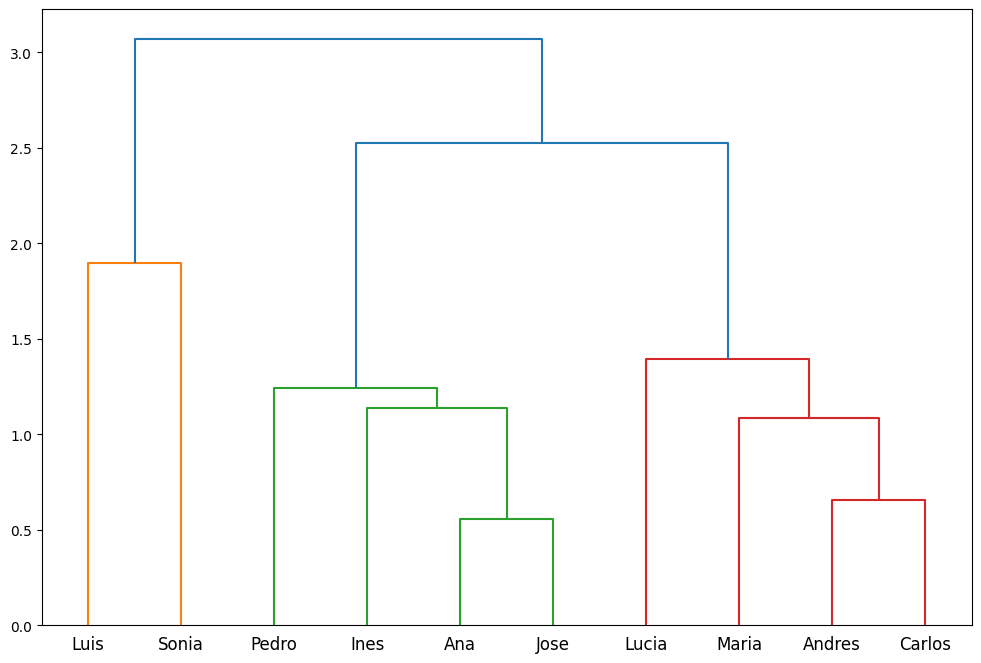

In [ ]:
#para realizar los dendogramas
fig, ax = plt.subplots(1,1, figsize = (12,8), dpi = 100)  #que nada mas sea un grafico de 1*1  dpi es para que el grafico salga con buena resolucion
dendrogram(single_res,labels= datos.index.tolist(),ax=ax)  #se utiliza sigle_res que es el salto minimo, estoy pasando el  indice a una lista, ax es la configuracion del grafico

## 12. Dendrograma con Complete Linkage (salto máximo)

Dendrograma usando el método **complete**: une los clusters cuyos puntos **más lejanos** están a menor distancia.

Característica: tiende a generar clusters **compactos y de tamaño similar**. Es más conservador que single.

{'icoord': [[5.0, 5.0, 15.0, 15.0],
  [25.0, 25.0, 35.0, 35.0],
  [45.0, 45.0, 55.0, 55.0],
  [30.0, 30.0, 50.0, 50.0],
  [65.0, 65.0, 75.0, 75.0],
  [85.0, 85.0, 95.0, 95.0],
  [70.0, 70.0, 90.0, 90.0],
  [40.0, 40.0, 80.0, 80.0],
  [10.0, 10.0, 60.0, 60.0]],
 'dcoord': [[0.0,
   np.float64(1.8947295321496418),
   np.float64(1.8947295321496418),
   0.0],
  [0.0, np.float64(0.5567764362830023), np.float64(0.5567764362830023), 0.0],
  [0.0, np.float64(1.3379088160259653), np.float64(1.3379088160259653), 0.0],
  [np.float64(0.5567764362830023),
   np.float64(1.6852299546352718),
   np.float64(1.6852299546352718),
   np.float64(1.3379088160259653)],
  [0.0, np.float64(0.6557438524301998), np.float64(0.6557438524301998), 0.0],
  [0.0, np.float64(1.392838827718412), np.float64(1.392838827718412), 0.0],
  [np.float64(0.6557438524301998),
   np.float64(1.9467922333931782),
   np.float64(1.9467922333931782),
   np.float64(1.392838827718412)],
  [np.float64(1.6852299546352718),
   np.float64(4.

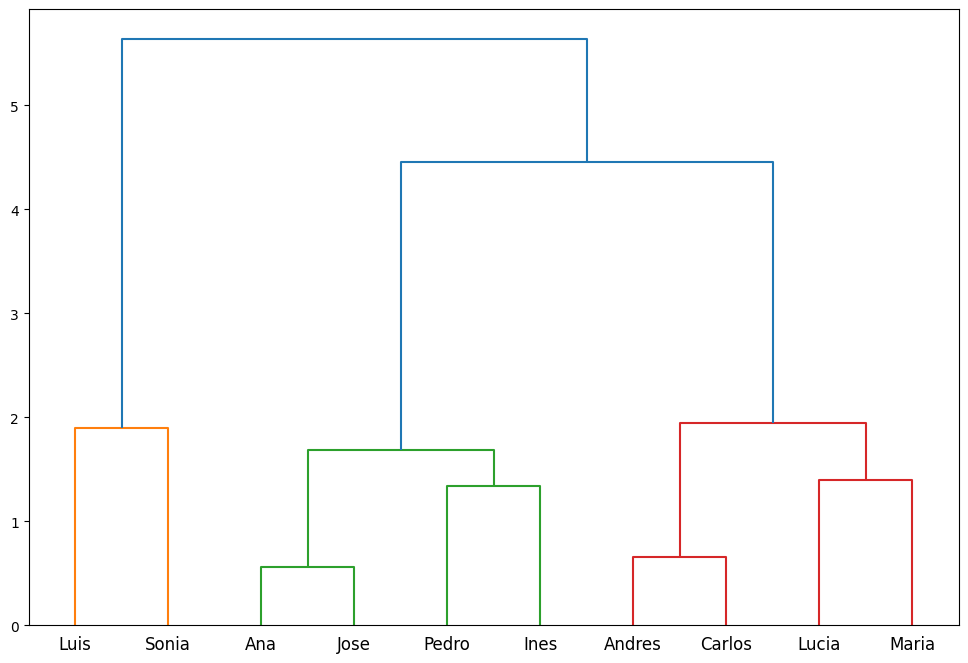

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (12,8), dpi = 100)
dendrogram(complete_res,labels= datos.index.tolist(),ax=ax)

## 13. Dendrograma con Average Linkage (promedio)

Dendrograma usando el método **average**: la distancia entre dos clusters es el **promedio** de las distancias entre todos los pares de puntos.

Es un buen punto medio entre `single` y `complete`.

{'icoord': [[5.0, 5.0, 15.0, 15.0],
  [25.0, 25.0, 35.0, 35.0],
  [45.0, 45.0, 55.0, 55.0],
  [30.0, 30.0, 50.0, 50.0],
  [65.0, 65.0, 75.0, 75.0],
  [85.0, 85.0, 95.0, 95.0],
  [70.0, 70.0, 90.0, 90.0],
  [40.0, 40.0, 80.0, 80.0],
  [10.0, 10.0, 60.0, 60.0]],
 'dcoord': [[0.0,
   np.float64(1.8947295321496418),
   np.float64(1.8947295321496418),
   0.0],
  [0.0, np.float64(0.5567764362830023), np.float64(0.5567764362830023), 0.0],
  [0.0, np.float64(1.3379088160259653), np.float64(1.3379088160259653), 0.0],
  [np.float64(0.5567764362830023),
   np.float64(1.393813395859142),
   np.float64(1.393813395859142),
   np.float64(1.3379088160259653)],
  [0.0, np.float64(0.6557438524301998), np.float64(0.6557438524301998), 0.0],
  [0.0, np.float64(1.392838827718412), np.float64(1.392838827718412), 0.0],
  [np.float64(0.6557438524301998),
   np.float64(1.569701754475642),
   np.float64(1.569701754475642),
   np.float64(1.392838827718412)],
  [np.float64(1.393813395859142),
   np.float64(3.68865

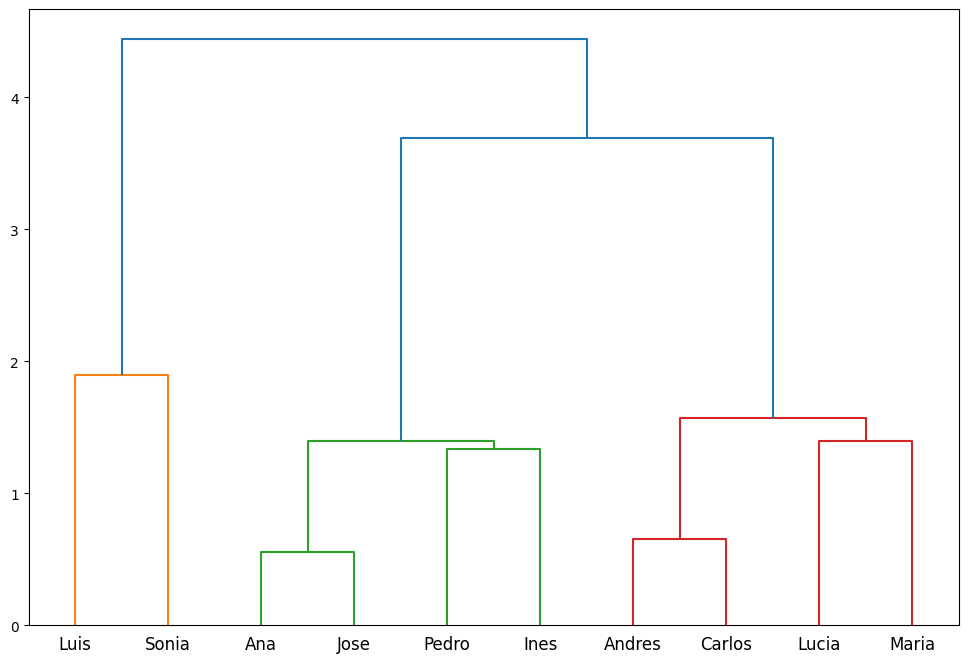

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (12,8), dpi = 100)
dendrogram(average_res,labels= datos.index.tolist(),ax=ax)

## 14. Dendrograma con Ward

Dendrograma usando el método **Ward**, el más popular en la práctica.

En cada paso une los clusters de forma que el aumento de la **varianza interna total** sea mínimo. Suele producir clusters **bien definidos y de tamaño parecido**.

Es el dendrograma que usaremos para tomar la decisión de cuántos clusters formar.

{'icoord': [[5.0, 5.0, 15.0, 15.0],
  [25.0, 25.0, 35.0, 35.0],
  [10.0, 10.0, 30.0, 30.0],
  [45.0, 45.0, 55.0, 55.0],
  [65.0, 65.0, 75.0, 75.0],
  [85.0, 85.0, 95.0, 95.0],
  [70.0, 70.0, 90.0, 90.0],
  [50.0, 50.0, 80.0, 80.0],
  [20.0, 20.0, 65.0, 65.0]],
 'dcoord': [[0.0,
   np.float64(0.5567764362830023),
   np.float64(0.5567764362830023),
   0.0],
  [0.0, np.float64(1.3379088160259653), np.float64(1.3379088160259653), 0.0],
  [np.float64(0.5567764362830023),
   np.float64(1.7117242768623688),
   np.float64(1.7117242768623688),
   np.float64(1.3379088160259653)],
  [0.0, np.float64(1.8947295321496418), np.float64(1.8947295321496418), 0.0],
  [0.0, np.float64(0.6557438524301998), np.float64(0.6557438524301998), 0.0],
  [0.0, np.float64(1.392838827718412), np.float64(1.392838827718412), 0.0],
  [np.float64(0.6557438524301998),
   np.float64(1.9862024066041202),
   np.float64(1.9862024066041202),
   np.float64(1.392838827718412)],
  [np.float64(1.8947295321496418),
   np.float64(6.

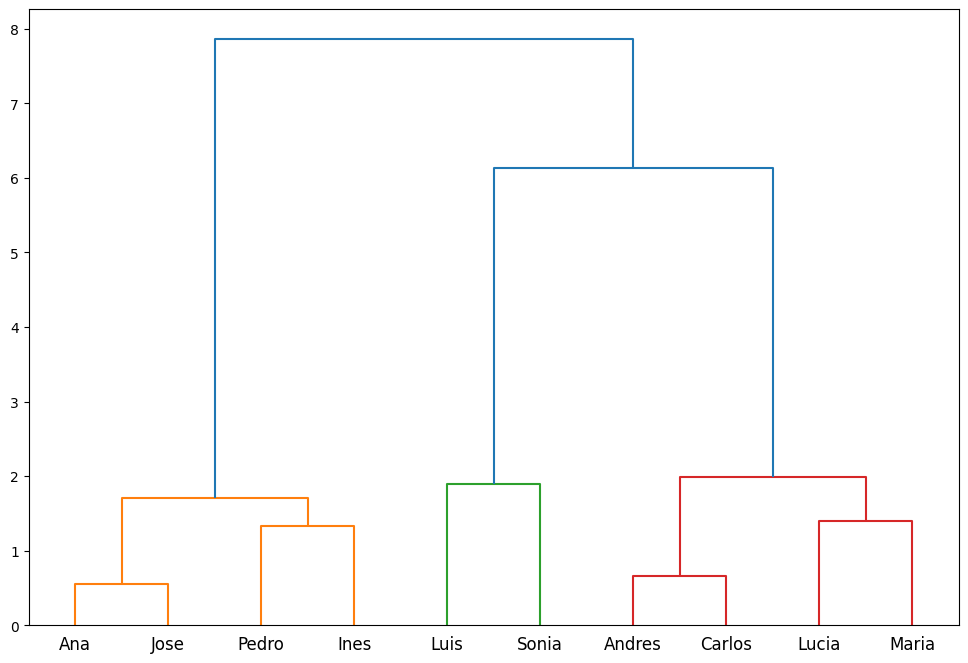

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (12,8), dpi = 100)
dendrogram(ward_res,labels = datos.index.tolist(),ax = ax)

## 15. Elegir el número de clusters (cortar el dendrograma)

Para decidir cuántos clusters formar, dibujamos **líneas horizontales** sobre el dendrograma de Ward.

- El número de clusters es **igual a la cantidad de ramas verticales** que la línea cruza.
- Una línea en altura **7.25** corta en **2 clusters**.
- Una línea en altura **4** corta en **3 clusters**.

Una buena regla práctica: cortar por una zona donde haya un **salto vertical grande** entre uniones (significa que después de ese punto se están uniendo grupos muy diferentes).

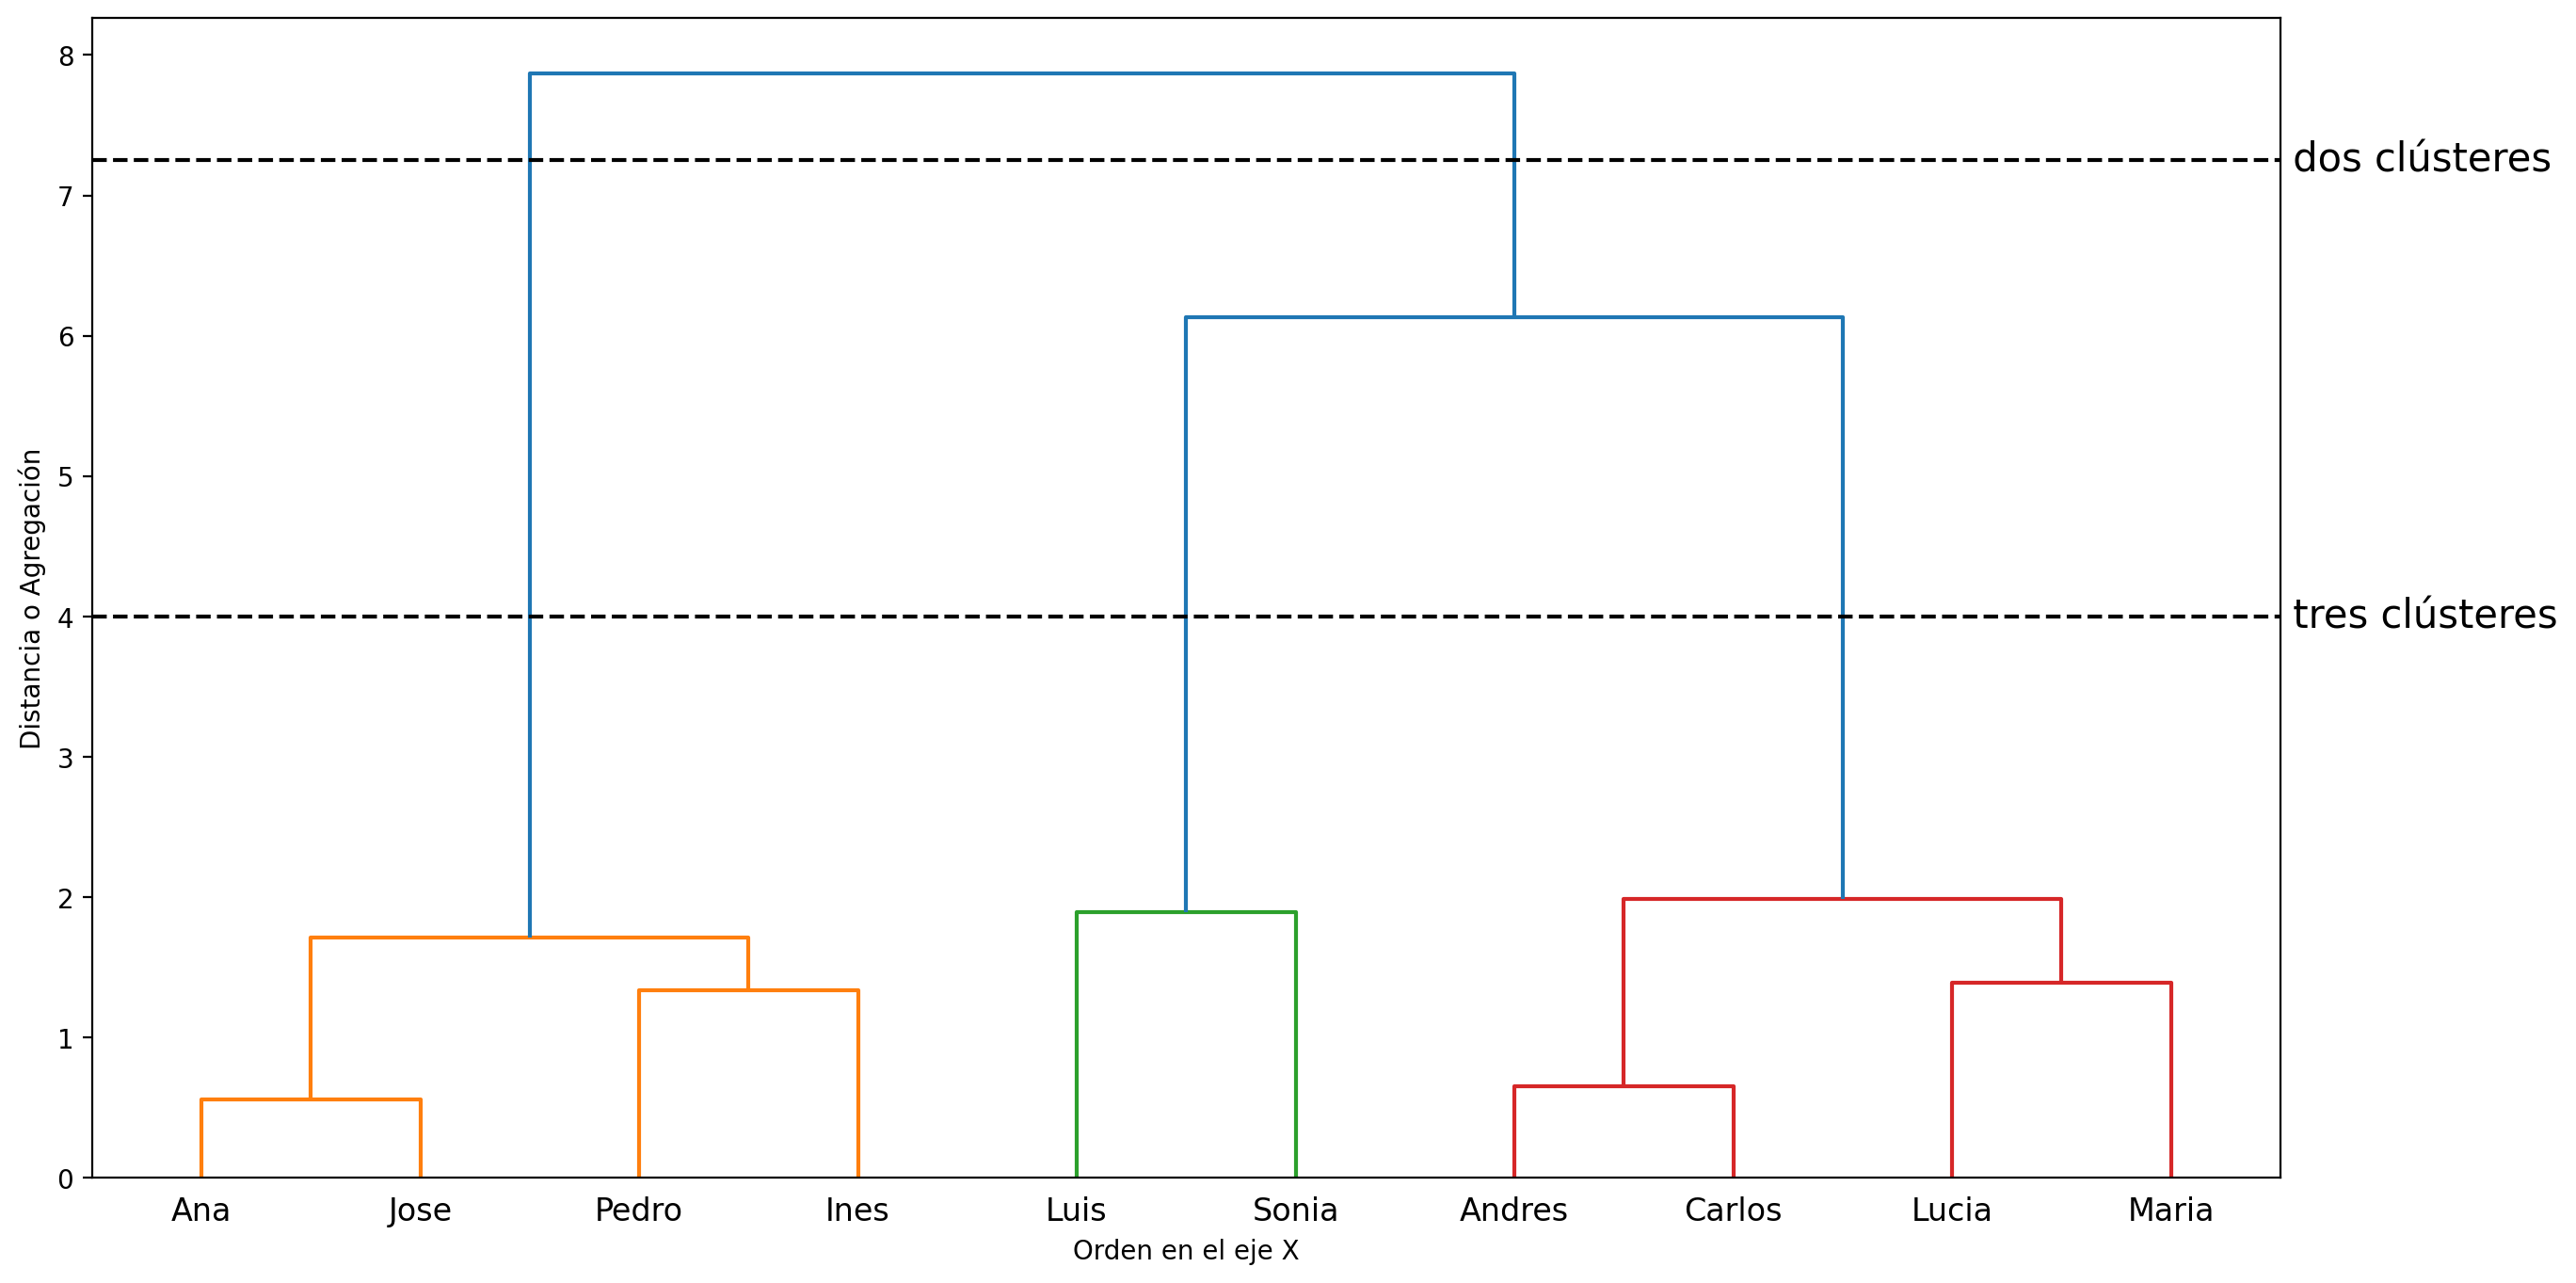

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (15,8), dpi = 200)
dendrogram(ward_res, labels = datos.index.tolist())

limites = ax.get_xbound()
ax.plot(limites, [7.25, 7.25], '--', c='k')
ax.plot(limites, [4, 4], '--', c='k')
ax.text(limites[1], 7.25, ' dos clústeres', va = 'center', fontdict={'size': 15})
ax.text(limites[1], 4, ' tres clústeres',   va = 'center', fontdict={'size': 15})
ax.set_xlabel("Orden en el eje X")
ax.set_ylabel("Distancia o Agregación")
plt.show()

## 16. Obtener las etiquetas de cluster

Usamos `fcluster` para **cortar el dendrograma** y asignar cada estudiante a un cluster.

- `linkage(datos, method='ward', metric='euclidean')` calcula la matriz de enlaces con Ward.
- `fcluster(..., 3, criterion='maxclust')` corta el árbol para obtener **3 clusters**.
- Restamos `1` para que los clusters se enumeren desde **0** (convención de Python).

El array resultante indica a qué cluster pertenece cada estudiante (en el orden de las filas de `datos`).

In [ ]:
grupos = fcluster(linkage(datos, method = 'ward', metric='euclidean'), 3, criterion = 'maxclust')
grupos = grupos-1 # Se resta 1 para que los clústeres se enumeren de 0 a (K-1), como usualmente lo hace Python
# El siguiente print es para ver en qué cluster quedó cada individuo
print(grupos)

[2 0 0 1 2 0 2 0 1 2]


## 17. Calcular los centros de cada cluster

Aunque el clustering jerárquico no produce centros internamente, calculamos el **promedio de cada variable** por cluster usando la función `centroide` definida al principio.

Esos promedios nos servirán para **interpretar** y comparar los grupos en los siguientes gráficos.

In [ ]:
centros = np.array(pd.concat([centroide(0, datos, grupos),
                              centroide(1, datos, grupos),
                              centroide(2, datos, grupos)]))
print(centros)

[[7.7   9.475 7.625 7.75  6.75 ]
 [5.5   6.25  6.5   6.25  8.85 ]
 [6.525 6.525 8.475 8.875 7.375]]


## 18. Interpretar los clusters con gráfico de barras

Graficamos los centros con `bar_plot`. Vemos, para cada cluster, el **perfil promedio en cada materia**.

Esto permite responder rápido: *¿cómo es el estudiante típico de cada grupo?*

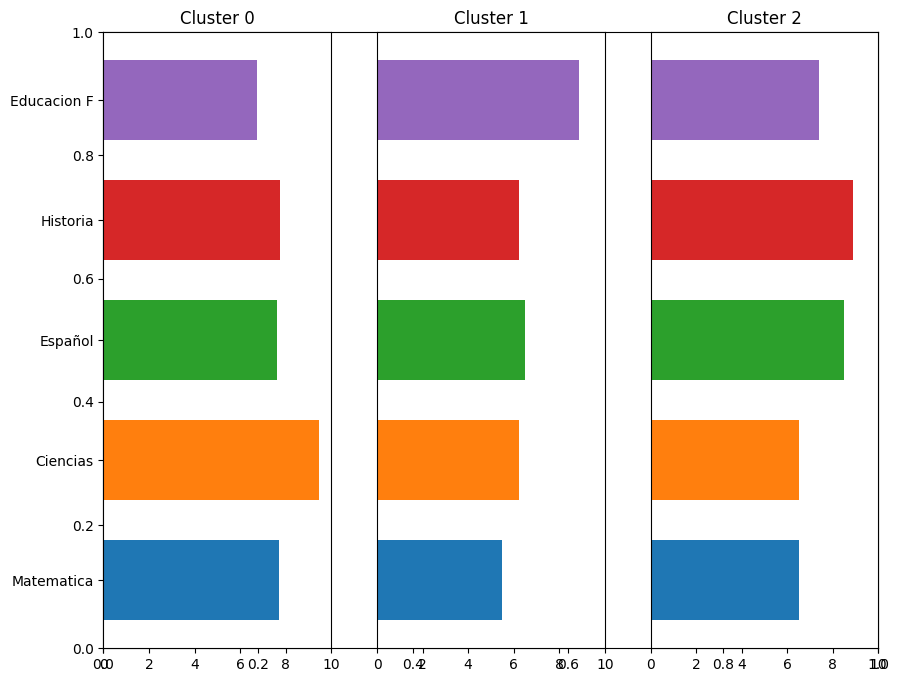

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (10,8))
bar_plot(centros, datos.columns)
plt.show()

## 19. Recalcular las etiquetas (preparación para el radar)

Volvemos a aplicar `fcluster` con 3 clusters. El resultado es el mismo que antes; se repite el cálculo para mantener el código autocontenido antes del siguiente gráfico.

In [ ]:
grupos = fcluster(linkage(datos, method = 'ward', metric='euclidean'), 3, criterion = 'maxclust')
grupos = grupos-1 # Se resta 1 para que los clústeres se enumeren de 0 a (K-1), como usualmente lo hace Python
# El siguiente print es para ver en qué cluster quedó cada individuo
print(grupos)

[2 0 0 1 2 0 2 0 1 2]


## 20. Recalcular los centros (preparación para el radar)

Volvemos a calcular los centros de los 3 clusters con la función `centroide`. De nuevo, mismos valores que arriba, listos para alimentar al `radar_plot`.

In [ ]:
centros = np.array(pd.concat([centroide(0, datos, grupos),
                              centroide(1, datos, grupos),
                              centroide(2, datos, grupos)]))
print(centros)

[[7.7   9.475 7.625 7.75  6.75 ]
 [5.5   6.25  6.5   6.25  8.85 ]
 [6.525 6.525 8.475 8.875 7.375]]


## 21. Interpretar los clusters con gráfico de radar

Visualizamos los centros con `radar_plot`. Cada polígono representa un cluster en los 5 ejes (materias).

Es la mejor forma de ver de un vistazo en qué materias destaca o flaquea cada grupo de estudiantes, y comparar todos los clusters al mismo tiempo.

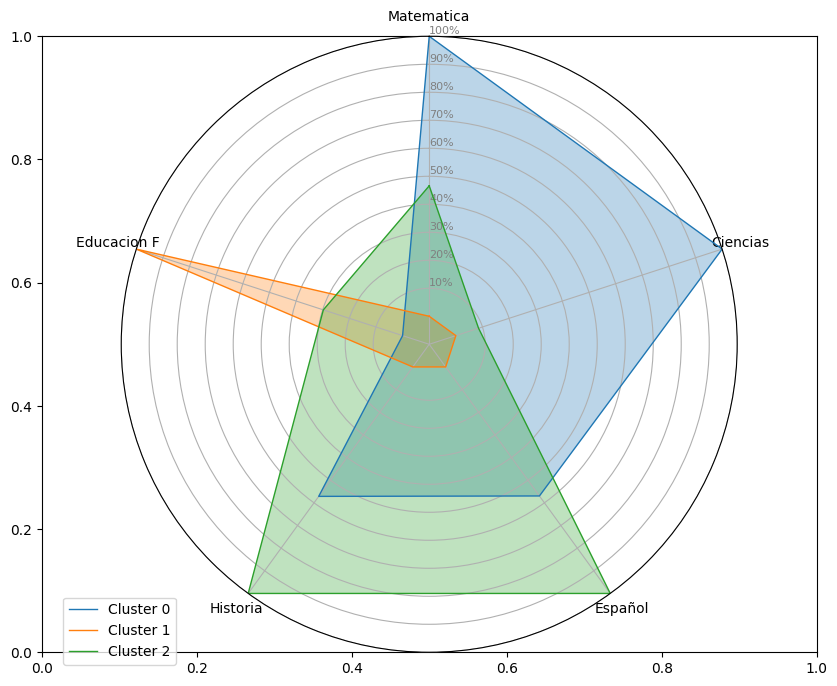

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (10,8))
radar_plot(centros, datos.columns)
plt.show()